В данном документе описывается математическая формализация, архитектура и алгоритм обучения экспериментальной модели FactorizedMazeTRM (Tiny Recurrent Models). В основе подхода лежит идея децентрализованного поиска глобального маршрута в графе/матрице с помощью ансамбля рекуррентных слоев-агентов, коммуницирующих через локальный обмен сообщениями (Message Passing) и глобальное внимание (Self-Attention), приходящих к финальному решению через операцию факторизованного логического консенсуса.

Вместо классического обратного распространения ошибки (Backpropagation), глубинная рекурсия оптимизируется градиентно-независимым методом Agent-wise SPSA (Simultaneous Perturbation Stochastic Approximation).
##1.  Архитектура агентов.
Модель параметризована $N$ независимыми агентами. Каждый агент представляет собой распределенную систему: каждая клетка лабиринта использует одну и ту же копию агента (веса $\theta_i$ разделены между всеми пространственными координатами).На каждом шаге рекурсии (времени) $t \in \{0, \dots, T\}$, агент $i$ для каждой клетки лабиринта оперирует следующими компонентами:$s_i^t$ — скрытое состояние клетки (локальная память).$m_{i, \text{dir}}^t$ — входящие локальные сообщения от 4-х соседей ($\text{dir} \in \{\text{up, down, left, right}\}$).$M_{\text{team}}^t$ — глобальная маска команды, вычисленная на предыдущем шаге рекурсии.$x_{\text{emb}}$ — статический пространственный эмбеддинг клетки.

##2.Механизм внимания:
$$s_{\text{norm}} = \text{LayerNorm}(s_i^t)$$ $$s_{\text{attn}} = s_i^t + \text{MultiheadAttention}(Q=s_{\text{norm}}, K=s_{\text{norm}}, V=s_{\text{norm}})$$

##3. Fusion:
Эмбэддинг, память, сообщения соседей и коллективное решение с прошлого такта объединяются в один вектор:
$$\text{inp} = \Big[ x_{\text{emb}} \mathbin{\Vert} s_{\text{attn}} \mathbin{\Vert} m_{i, \text{up}}^t \mathbin{\Vert} m_{i, \text{down}}^t \mathbin{\Vert} m_{i, \text{left}}^t \mathbin{\Vert} m_{i, \text{right}}^t \mathbin{\Vert} M_{\text{team}}^t \Big]$$$$\text{fused} = \text{GELU}\Big(\text{LayerNorm}\big(\mathbf{W}_f \cdot \text{inp} + \mathbf{b}_f\big)\Big)$$

##4.Обновление состояния (MLP + Residual):$$s_i^{t+1} = s_{\text{attn}} + \text{MLP}\Big(\text{LayerNorm}(\text{fused})\Big)$$

##5.Выходы агента:
Агент транслирует новое сообщение для соседей на следующий шаг и предсказывает свою локальную маску вероятности прохождения пути:$$m_i^{t+1} = \mathbf{W}_m \cdot s_i^{t+1} + \mathbf{b}_m$$$$P_i^{t+1} = \sigma\big(\mathbf{W}_p \cdot s_i^{t+1} + \mathbf{b}_p\big)$$

##6.Механизм консенсуса:
В архитектуре реализован консенсус через произведениие предсказанных агентами вероятностей,
$$M_{\text{team}}^{t+1} = \prod_{i=1}^{N} P_i^{t+1}$$
Таким образом, выходом сети является маска $$M_{\text{team}}^{t+1},$$ полученная на последнем рекуррентном вызове.

##7. Гиперпараметры
Гиперпараметрами модели являются число агентов (num_agents), глубина рекурсии (time_steps), размерность скрытого пространства (hidden), размерность вектора - сообщения  (message_dim).

Стоит отметить, что предложенная архитектура не является ансамблевой в прямом смысле этого слова, так как агенты взаимодействуют в процессе обучения друг взаимодействуют друг с другом. Даже при num_agents = 1 мы имеем распределенную систему,в модели сохраняется диалог между экземплярами одного и того же агента в соседних клетках, всякий агент также принимает свое же решение по клетке на прошлом такте. (сам консенсус вырождается в простое предсказание вероятности).

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random


def sample_maze(batch, size, wall_p, device):
    xs, ys = [], []
    for _ in range(batch):
        rng = np.random.default_rng(random.randrange(1 << 30))
        wall = rng.random((size, size)) < wall_p
        free = np.argwhere(~wall)
        if len(free) < 2:
            wall[:] = False
            free = np.argwhere(~wall)
        sidx, gidx = rng.choice(len(free), size=2, replace=False)
        start, goal = tuple(free[sidx]), tuple(free[gidx])

        reach = np.zeros((size, size), dtype=np.int64)
        q = [start]; reach[start] = 1
        for r, c in q:
            for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                rr, cc = r + dr, c + dc
                if 0 <= rr < size and 0 <= cc < size and not wall[rr, cc] and not reach[rr, cc]:
                    reach[rr, cc] = 1
                    q.append((rr, cc))

        x = np.zeros((size, size, 3), dtype=np.float32)
        x[..., 0] = wall.astype(np.float32)
        x[start[0], start[1], 1] = 1.0
        x[goal[0], goal[1], 2] = 1.0
        xs.append(x.reshape(size * size, 3))
        ys.append(reach.reshape(-1))

    return (
        torch.tensor(np.stack(xs), dtype=torch.float32, device=device),
        torch.tensor(np.stack(ys), dtype=torch.float32, device=device) # Теперь float32 для BCE
    )


In [3]:
def compute_f1_score(mask_probs, target):
    preds = (mask_probs > 0.5).float().view(-1)
    target_flat = target.view(-1)
    tp = ((preds == 1) & (target_flat == 1)).sum()
    fp = ((preds == 1) & (target_flat == 0)).sum()
    fn = ((preds == 0) & (target_flat == 1)).sum()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return (2 * precision * recall / (precision + recall + 1e-8)).item()

def compute_grid_accuracy(mask_probs, target):
    preds = (mask_probs > 0.5).view(target.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    return (preds == target_flat).all(dim=-1).float().mean().item()

In [4]:
class AttentionAgentCell(nn.Module):
    def __init__(self, hidden, message_dim, n_heads=2):
        super().__init__()
        self.hidden = hidden
        self.message_dim = message_dim

        self.self_attn = nn.MultiheadAttention(embed_dim=hidden, num_heads=n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)

        input_dim = hidden + hidden + message_dim * 4 + 1

        self.fusion = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU()
        )

        self.mlp = nn.Sequential(
            nn.Linear(hidden, hidden * 2),
            nn.GELU(),
            nn.Linear(hidden * 2, hidden)
        )

        self.msg_head = nn.Linear(hidden, message_dim)
        self.mask_head = nn.Linear(hidden, 1)
        nn.init.constant_(self.mask_head.bias, 1.0)

    def forward(self, x_emb, s_prev, m_up, m_down, m_left, m_right, prev_team_mask):

        s_norm = self.norm1(s_prev)
        attn_out, _ = self.self_attn(s_norm, s_norm, s_norm)
        s_attn = s_prev + attn_out


        inp = torch.cat([x_emb, s_attn, m_up, m_down, m_left, m_right, prev_team_mask], dim=-1)
        fused = self.fusion(inp)


        s_new = s_attn + self.mlp(self.norm2(fused))

        msg = self.msg_head(s_new)
        mask_prob = torch.sigmoid(self.mask_head(s_new))

        return s_new, msg, mask_prob


class FactorizedMazeTRM(nn.Module):
    def __init__(self, height=5, width=5, hidden=24, message_dim=12, num_agents=3, time_steps=8):
        super().__init__()
        self.height, self.width = height, width
        self.hidden, self.message_dim = hidden, message_dim
        self.num_agents, self.time_steps = num_agents, time_steps

        self.input_projection = nn.Linear(3, hidden)
        self.pos_emb_x = nn.Parameter(torch.randn(width, hidden) * 0.02, requires_grad=False)
        self.pos_emb_y = nn.Parameter(torch.randn(height, hidden) * 0.02, requires_grad=False)

        self.agents = nn.ModuleList([
            AttentionAgentCell(hidden, message_dim) for _ in range(num_agents)
        ])

    def forward(self, x):
        b, n_cells, _ = x.shape
        h, w = self.height, self.width

        pe_x = self.pos_emb_x[:h, :].unsqueeze(1)
        pe_y = self.pos_emb_y[:w, :].unsqueeze(0)
        grid_pe = (pe_x + pe_y).view(-1, self.hidden).unsqueeze(0)
        x_emb = self.input_projection(x) + grid_pe

        states = [torch.zeros(b, n_cells, self.hidden, device=x.device) for _ in range(self.num_agents)]
        msgs = [torch.zeros(b, n_cells, self.message_dim, device=x.device) for _ in range(self.num_agents)]


        team_mask = torch.ones(b, n_cells, 1, device=x.device)

        for t in range(self.time_steps):
            new_states, new_msgs, agent_masks = [], [], []

            for i, agent in enumerate(self.agents):
                m_grid = msgs[i].view(b, h, w, self.message_dim).permute(0, 3, 1, 2)
                m_pad = F.pad(m_grid, (1, 1, 1, 1), mode='constant', value=0.0)
                m_up    = m_pad[:, :, 0:h,   1:w+1].permute(0, 2, 3, 1).reshape(b, n_cells, self.message_dim)
                m_down  = m_pad[:, :, 2:h+2, 1:w+1].permute(0, 2, 3, 1).reshape(b, n_cells, self.message_dim)
                m_left  = m_pad[:, :, 1:h+1, 0:w  ].permute(0, 2, 3, 1).reshape(b, n_cells, self.message_dim)
                m_right = m_pad[:, :, 1:h+1, 2:w+2].permute(0, 2, 3, 1).reshape(b, n_cells, self.message_dim)

                s, m, prob = agent(x_emb, states[i], m_up, m_down, m_left, m_right, team_mask)

                new_states.append(s)
                new_msgs.append(m)
                agent_masks.append(prob)

            team_mask = agent_masks[0]
            for i in range(1, self.num_agents):
                team_mask = team_mask * agent_masks[i]

            states, msgs = new_states, new_msgs

        return {"final_mask": team_mask.squeeze(-1)} # [B, N]

In [21]:
import json
import matplotlib.pyplot as plt

LOG_FILE_PATH = "quasi_ensemble_training_log.json"
training_history = {
    "epoch": [],
    "train_bce": [],
    "test_f1": [],
    "test_grid_acc": []
}

In [22]:
def get_agent_theta(agent):
    return torch.cat([p.data.view(-1) for p in agent.parameters()]).clone()

def set_agent_theta(agent, theta):
    pointer = 0
    for p in agent.parameters():
        numel = p.numel()
        p.data.copy_(theta[pointer:pointer + numel].view_as(p))
        pointer += numel

def get_spsa_lr(step, warmup_steps = 5000, target_lr = 0.05, decay_rate = 0.995):
  if step < warmup_steps :
    return target_lr*(step/warmup_steps)
  else:
    return target_lr*(decay_rate ** (step - warmup_steps))

def get_dynamic_T(epoch, total_epochs, min_T=5, max_T=20):
    progress = min(1.0, epoch / (total_epochs * 0.5))
    current_T = int(min_T + progress * (max_T - min_T))
    return current_T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

H, W = 5, 5
wall_prob = 0.35
batch_size, steps_per_epoch, num_epochs = 64, 20, 60

model = FactorizedMazeTRM(height=H, width=W, hidden=24, message_dim=12, num_agents=3, time_steps=8).to(device)
trainable_agents = list(model.agents)

a_0, c_0 = 0.06, 0.015
alpha, gamma_spsa = 0.602, 0.101
A, eps = 50, 1e-7
global_step_spsa = 0

print("-" * 55)
print(f"{'Эпоха':^6} | {'BCE Loss':^10} | {'F1 Score':^10} | {'Grid Acc':^10}")
print("-" * 55)

for epoch in range(num_epochs):
    model.train()
    epoch_bce = 0.0
    current_T = get_dynamic_T(epoch, num_epochs, min_T = 5, max_T = 20)
    model.time_steps = current_T
    for step in range(steps_per_epoch):
        current_lr = get_spsa_lr(step)
        x_batch, y_batch = sample_maze(batch_size, size=H, wall_p=wall_prob, device=device)
        global_step_spsa += 1
        ak = a_0 / (global_step_spsa + A) ** alpha
        #ak = current_lr
        ck = c_0 / (global_step_spsa) ** gamma_spsa
        thetas_base = [get_agent_theta(agent) for agent in trainable_agents]

        for i, agent in enumerate(trainable_agents):
            th = thetas_base[i]
            delta = torch.bernoulli(torch.full_like(th, 0.5)) * 2 - 1

            set_agent_theta(agent, th + ck * delta)
            with torch.no_grad():
                out_plus = model(x_batch)
                loss_plus = F.binary_cross_entropy(out_plus["final_mask"].view(-1), y_batch.view(-1))

            set_agent_theta(agent, th - ck * delta)
            with torch.no_grad():
                out_minus = model(x_batch)
                loss_minus = F.binary_cross_entropy(out_minus["final_mask"].view(-1), y_batch.view(-1))

            set_agent_theta(agent, th)
            spsa_grad = ((loss_plus - loss_minus) / (2 * ck + eps)) * delta
            spsa_grad = torch.clamp(spsa_grad, -1.0, 1.0)
            thetas_base[i] = th - ak * spsa_grad
            set_agent_theta(agent, thetas_base[i])
            if i == 0:
                epoch_bce += ((loss_plus.item() + loss_minus.item()) / 2)
    model.eval()
    with torch.no_grad():
        x_test, y_test = sample_maze(150, size=H, wall_p=wall_prob, device=device)
        out_test = model(x_test)
        test_f1 = compute_f1_score(out_test["final_mask"], y_test)
        test_grid = compute_grid_accuracy(out_test["final_mask"], y_test)

    avg_bce = epoch_bce / steps_per_epoch

    training_history["epoch"].append(epoch + 1)
    training_history["train_bce"].append(float(avg_bce))
    training_history["test_f1"].append(float(test_f1))
    training_history["test_grid_acc"].append(float(test_grid))

    with open(LOG_FILE_PATH, "w") as f:
        json.dump(training_history, f, indent=4)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f"{epoch+1:06d} | {avg_bce:10.4f} | {test_f1:10.4f} | {test_grid:13.4f}")

-------------------------------------------------------
Эпоха  |  BCE Loss  |  F1 Score  |  Grid Acc 
-------------------------------------------------------
000001 |     0.6705 |     0.8596 |        0.1600
000005 |     0.5037 |     0.8172 |        0.0867
000010 |     0.3591 |     0.8810 |        0.3000
000015 |     0.3374 |     0.8868 |        0.2933
000020 |     0.3050 |     0.8723 |        0.3533
000025 |     0.3122 |     0.8683 |        0.3067
000030 |     0.3108 |     0.8783 |        0.3667
000035 |     0.3187 |     0.8948 |        0.4267
000040 |     0.2958 |     0.8832 |        0.3400
000045 |     0.2973 |     0.8835 |        0.4333
000050 |     0.3023 |     0.8653 |        0.3800
000055 |     0.3035 |     0.8845 |        0.3800
000060 |     0.2947 |     0.9078 |        0.4400


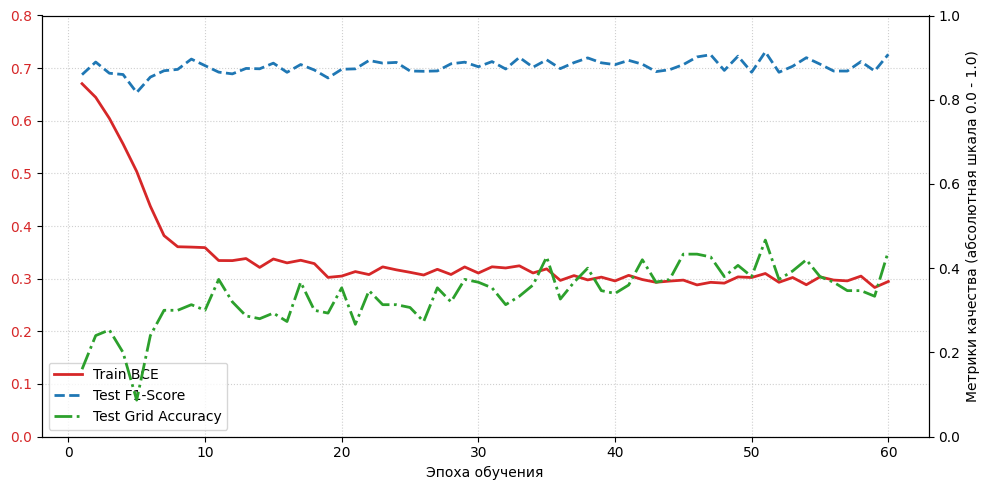

In [27]:

with open("quasi_ensemble_training_log.json", "r") as f:
    history = json.load(f)

epochs = history["epoch"]

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=100)

color = 'tab:red'
ax1.set_xlabel('Эпоха обучения')
ax1.set_ylabel('', color=color)
ax1.plot(epochs, history["train_bce"], color=color, lw=2, label='Train BCE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_ylim(0.0, 0.8)


ax2 = ax1.twinx()
color_f1 = 'tab:blue'
color_grid = 'tab:green'

ax2.set_ylabel('Метрики качества (абсолютная шкала 0.0 - 1.0)', color='black')
ax2.plot(epochs, history["test_f1"], color=color_f1, lw=2, linestyle='--', label='Test F1-Score')
ax2.plot(epochs, history["test_grid_acc"], color=color_grid, lw=2, linestyle='-.', label='Test Grid Accuracy')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0.0, 1.0)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('', fontsize=12, pad=15)
fig.tight_layout()
plt.show()